## Import libraries

In [63]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers
from tabulate import tabulate
from pydantic import BaseModel
from typing import Dict, List
import joblib
import json
import time
import os

MODEL_DIR  = "models"
MODELS_JSON = "models.json"
os.makedirs(MODEL_DIR, exist_ok=True)

def _load_registry() -> dict:
    if os.path.exists(MODELS_JSON):
        with open(MODELS_JSON) as f:
            return json.load(f)
    return {}

def _save_registry(registry: dict):
    with open(MODELS_JSON, "w") as f:
        json.dump(registry, f, indent=2)


In [65]:
# Configure TensorFlow to use GPU > TPU > CPU (whichever is available)

def configure_tf_device():
    # Suppress verbose TF/CUDA logs before device selection
    os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

    # 1. Try TPU
    try:
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        print(f"TPU detected — using TPUStrategy ({strategy.num_replicas_in_sync} cores)")
        return strategy, "TPU"
    except (ValueError, tf.errors.NotFoundError):
        pass

    # 2. Try GPU
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            strategy = tf.distribute.MirroredStrategy()
            print(f"GPU detected — using MirroredStrategy ({len(gpus)} GPU(s): "
                  f"{[g.name for g in gpus]})")
            return strategy, "GPU"
        except RuntimeError as e:
            print(f"GPU found but could not be configured: {e}")

    # 3. Fallback to CPU
    strategy = tf.distribute.get_strategy()   # default (no-op) strategy
    print("No GPU/TPU found — falling back to CPU")
    return strategy, "CPU"

tf_strategy, tf_device = configure_tf_device()


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
GPU detected — using MirroredStrategy (1 GPU(s): ['/physical_device:GPU:0'])


In [66]:

class ModelResult(BaseModel):
    model_name: str
    training_time_s: float
    inference_time_ms: float       # per-sample inference latency
    accuracy: float
    precision: float               # weighted
    recall: float                  # weighted
    f1_score: float                # weighted
    confusion_matrix: List[List[int]]
    per_class_metrics: Dict[str, Dict[str, float]]  # class label -> {precision, recall, f1-score, support}

    def to_summary_dict(self) -> dict:
        """Flat dict suitable for a summary comparison table row."""
        return {
            'Model':                   self.model_name,
            'Accuracy (%)':            round(self.accuracy  * 100, 3),
            'Precision (%)':           round(self.precision * 100, 3),
            'Recall (%)':              round(self.recall    * 100, 3),
            'F1-Score (%)':            round(self.f1_score  * 100, 3),
            'Train Time (s)':          round(self.training_time_s,  3),
            'Infer. Time (ms/sample)': round(self.inference_time_ms, 4),
        }


### Load data

In [67]:
# Read the dataset
df = pd.read_csv('CICEVSE2024_12classes_kmeans_rule_sampled1000.csv')


In [68]:
df

,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,...,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,Label
0,0.0,0.396825,0.500000,0.714286,0.135668,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
1,0.0,0.476190,0.500000,0.714286,0.347005,0.453333,0.176471,0.111111,0.001221,0.020408,...,0.230769,1.000000,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
2,0.0,0.317460,0.833333,0.857143,0.703655,0.346667,0.705882,0.777778,0.008286,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1
3,0.0,0.539683,0.500000,0.714286,0.942000,0.400000,0.705882,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,10
4,0.0,0.396825,0.500000,0.714286,0.152590,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35936,0.0,0.396825,0.500000,0.714286,0.660441,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
35937,0.0,0.539683,0.500000,0.714286,0.929381,0.400000,0.764706,0.777778,0.145495,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,2
35938,0.0,0.317460,0.833333,0.857143,0.690272,0.346667,0.705882,0.777778,0.045853,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,3
35939,0.0,0.539683,0.500000,0.714286,0.799344,0.400000,0.705882,0.777778,0.084077,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1


In [69]:
# print the class distribution of the last column
df['Label'].value_counts()

Label
7     7696
3     5807
1     4739
8     3690
2     3421
5     3110
11    2787
10    1898
9     1577
6     1044
4       90
0       82
Name: count, dtype: int64

| Name                                                   | Original Number of Samples | Reduced Subset | Label |
|--------------------------------------------------------|----------------------------|----------------|-------|
| Class 2 DoS: TCP floods                                | 721044                     | 7696           | 7     |
| Class 1 Discovery: Stealth SYN scanning                | 530946                     | 5807           | 3     |
| Class 1 Discovery: Port scanning                       | 426659                     | 4739           | 1     |
| Class 1 Discovery: Service detection                   | 292856                     | 3690           | 8     |
| Class 2 DoS: Identity rotation and rotation flood      | 262185                     | 3421           | 2    |
| Class 3 Reconnaissance: Vulnerability scan             | 231367                     | 3110           | 5     |
| Class 3 Reconnaissance: OS fingerprinting              | 140273                     | 2787           | 11    |
| Class 3 Reconnaissance: Aggressive scan                | 102522                     | 1898           | 10    |
| Class 2 DoS: UDP flood                                 | 32475                      | 1577           | 9     |
| Class 2 DoS: Slow request starvation                   | 4201                       | 1044           | 6     |
| Class 2 DoS: ICMP flood or fragmentation               | 90                         | 90             | 4     |
| Class 0 Normal                                         | 82                         | 82             | 0     |

/tmp/ipykernel_259202/3855248888.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right')


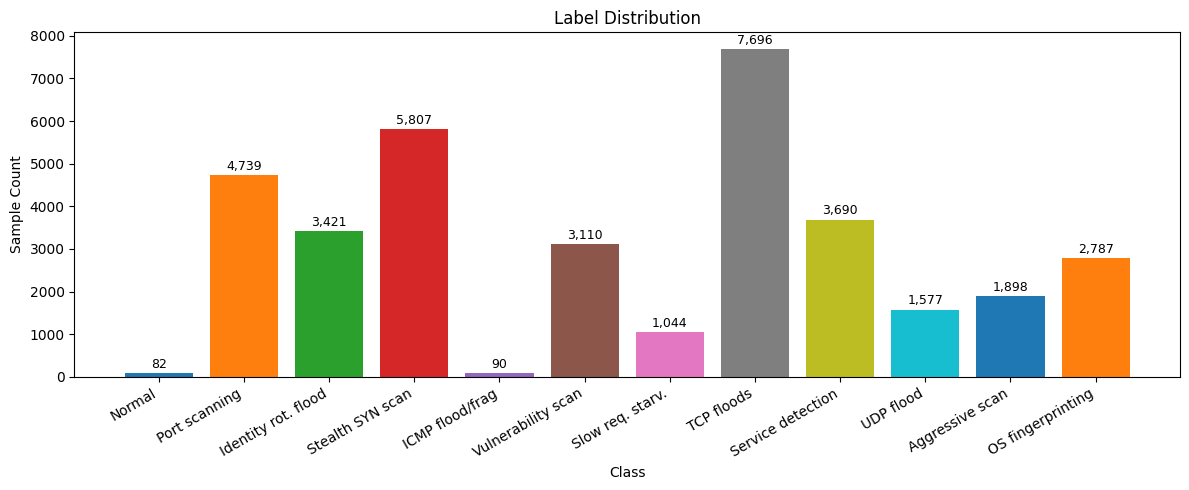

In [70]:
# Bar plot of label value counts with class names
label_names = {
    0: 'Normal',
    1: 'Port scanning',
    2: 'Identity rot. flood',
    3: 'Stealth SYN scan',
    4: 'ICMP flood/frag',
    5: 'Vulnerability scan',
    6: 'Slow req. starv.',
    7: 'TCP floods',
    8: 'Service detection',
    9: 'UDP flood',
    10: 'Aggressive scan',
    11: 'OS fingerprinting',
}

counts = df['Label'].value_counts().sort_index()
labels = [label_names[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, counts.values, color=sns.color_palette('tab10', len(counts)))
ax.set_xlabel('Class')
ax.set_ylabel('Sample Count')
ax.set_title('Label Distribution')
ax.set_xticklabels(labels, rotation=30, ha='right')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Data pre-processing

In [71]:
# Encode the dataset
labelencoder = LabelEncoder()
df.iloc[:, -1] = labelencoder.fit_transform(df.iloc[:, -1])


In [72]:
# min-max normalization
for column in df.columns[:-1]: # excluding the last column
    df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
    

In [73]:
# address empty values
if df.isnull().values.any() or np.isinf(df).values.any(): # if there is any empty or infinite values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace = True)

In [74]:
X = df.drop(['Label'],axis=1)
y = df.iloc[:, -1]

# Split the dataset into training and testing sets (80%, 20%)
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)


### Reference Models from Literature

| Paper | Link | Models |
|-------|------|--------|
| Tree-based Intelligent Intrusion Detection System in Internet of Vehicles | [arXiv:1910.08635](https://arxiv.org/pdf/1910.08635) | Random Forest, Decision Tree, Extra Tree, XGBoost |
| MTH-IDS: A Multitiered Hybrid Intrusion Detection System for Internet of Vehicles | [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9443234) | Multi-SVM, KNN |
|A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles| [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9838780) | VGG16, VGG19|
|Deep Learning Approach for Intelligent Intrusion Detection System| [IEEE Xplore](https://ieeexplore.ieee.org/abstract/document/8681044)| DNN, LR|
| | | LightGBM|


In [75]:
def train_xgboost(
    X_train, X_test, y_train, y_test,
    model_name: str = "XGBoost (default)",
    model_path: str = f"{MODEL_DIR}/xgboost.json",
    **xgb_kwargs,
) -> ModelResult:
    """Train an XGBoost classifier and return structured evaluation results."""
    registry = _load_registry()
    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        training_time = entry["training_time"]
        model_path = entry["model_path"]
        print(f"Loading cached {model_name} from {model_path}")
        model = xgb.XGBClassifier(**xgb_kwargs)
        model.load_model(model_path)
    else:
        model = xgb.XGBClassifier(random_state=42, **xgb_kwargs)
        start = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start
        model.save_model(model_path)
        registry[model_name] = {"training_time": training_time, "model_path": model_path}
        _save_registry(registry)

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy  = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix  = confusion_matrix(y_test, y_pred)
    report_dict  = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


xgb_result = train_xgboost(X_train, X_test, y_train, y_test, model_name="XGBoost (default)")
print(f"Done — {xgb_result.model_name}  |  Accuracy: {xgb_result.accuracy*100:.3f}%")


Loading cached XGBoost (default) from models/xgboost.json
Done — XGBoost (default)  |  Accuracy: 99.847%


In [76]:
def train_random_forest(
    X_train, X_test, y_train, y_test,
    model_name: str = "Random Forest",
    model_path: str = f"{MODEL_DIR}/random_forest.pkl",
    **kwargs,
) -> ModelResult:
    """Train a Random Forest classifier."""
    registry = _load_registry()
    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        training_time = entry["training_time"]
        model_path = entry["model_path"]
        print(f"Loading cached {model_name} from {model_path}")
        model = joblib.load(model_path)
    else:
        model = RandomForestClassifier(random_state=42, **kwargs)
        start = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start
        joblib.dump(model, model_path)
        registry[model_name] = {"training_time": training_time, "model_path": model_path}
        _save_registry(registry)

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


rf_result = train_random_forest(X_train, X_test, y_train, y_test)
print(f"Done — {rf_result.model_name}  |  Accuracy: {rf_result.accuracy*100:.3f}%")


Loading cached Random Forest from models/random_forest.pkl
Done — Random Forest  |  Accuracy: 99.917%


In [77]:
def train_decision_tree(
    X_train, X_test, y_train, y_test,
    model_name: str = "Decision Tree",
    model_path: str = f"{MODEL_DIR}/decision_tree.pkl",
    **kwargs,
) -> ModelResult:
    """Train a CART Decision Tree classifier."""
    registry = _load_registry()
    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        training_time = entry["training_time"]
        model_path = entry["model_path"]
        print(f"Loading cached {model_name} from {model_path}")
        model = joblib.load(model_path)
    else:
        model = DecisionTreeClassifier(random_state=42, **kwargs)
        start = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start
        joblib.dump(model, model_path)
        registry[model_name] = {"training_time": training_time, "model_path": model_path}
        _save_registry(registry)

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


dt_result = train_decision_tree(X_train, X_test, y_train, y_test)
print(f"Done — {dt_result.model_name}  |  Accuracy: {dt_result.accuracy*100:.3f}%")


Loading cached Decision Tree from models/decision_tree.pkl
Done — Decision Tree  |  Accuracy: 99.958%


In [78]:
def train_extra_trees(
    X_train, X_test, y_train, y_test,
    model_name: str = "Extra Trees",
    model_path: str = f"{MODEL_DIR}/extra_trees.pkl",
    **kwargs,
) -> ModelResult:
    """Train an Extra Trees (Extremely Randomized Trees) classifier."""
    registry = _load_registry()
    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        training_time = entry["training_time"]
        model_path = entry["model_path"]
        print(f"Loading cached {model_name} from {model_path}")
        model = joblib.load(model_path)
    else:
        model = ExtraTreesClassifier(random_state=42, **kwargs)
        start = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start
        joblib.dump(model, model_path)
        registry[model_name] = {"training_time": training_time, "model_path": model_path}
        _save_registry(registry)

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


et_result = train_extra_trees(X_train, X_test, y_train, y_test)
print(f"Done — {et_result.model_name}  |  Accuracy: {et_result.accuracy*100:.3f}%")


Loading cached Extra Trees from models/extra_trees.pkl
Done — Extra Trees  |  Accuracy: 99.819%


In [79]:
def train_svm(
    X_train, X_test, y_train, y_test,
    model_name: str = "Multi-SVM",
    model_path: str = f"{MODEL_DIR}/svm.pkl",
    n_iter: int = 20,
    cv: int = 3,
) -> ModelResult:
    """Train a multi-class SVM with RandomizedSearchCV over kernels and hyperparameters.
    Saves the best estimator found by the search."""
    registry = _load_registry()
    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        training_time = entry["training_time"]
        model_path = entry["model_path"]
        print(f"Loading cached {model_name} from {model_path}")
        if "best_params" in entry:
            print(f"Best params (from search): {entry['best_params']}")
            print(f"Best CV accuracy: {entry['best_cv_score']*100:.3f}%")
        model = joblib.load(model_path)
    else:
        param_dist = {
            'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
            'C':      np.logspace(-1, 2, 50).tolist(),                        # 0.1 → 100
            'gamma':  ['scale', 'auto'] + np.logspace(-4, 0, 20).tolist(),    # rbf/poly/sigmoid
            'degree': [2, 3, 4],                                               # poly only
            'coef0':  np.linspace(0, 1, 20).tolist(),                         # poly/sigmoid
        }

        print(f"Running RandomizedSearchCV for {model_name} "
              f"({n_iter} iterations, {cv}-fold CV) — this may take several minutes...")
        base = SVC(random_state=42)
        search = RandomizedSearchCV(
            base, param_dist,
            n_iter=n_iter, cv=cv,
            scoring='accuracy',
            n_jobs=-1,
            random_state=42,
            verbose=1,
        )

        start = time.time()
        search.fit(X_train, y_train)
        training_time = time.time() - start

        model = search.best_estimator_
        print(f"Best params: {search.best_params_}")
        print(f"Best CV accuracy: {search.best_score_*100:.3f}%")

        joblib.dump(model, model_path)
        registry[model_name] = {
            "training_time": training_time,
            "model_path": model_path,
            "best_params": search.best_params_,
            "best_cv_score": search.best_score_,
        }
        _save_registry(registry)

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy  = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix  = confusion_matrix(y_test, y_pred)
    report_dict  = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


svm_result = train_svm(X_train, X_test, y_train, y_test)
print(f"Done — {svm_result.model_name}  |  Accuracy: {svm_result.accuracy*100:.3f}%")


Running RandomizedSearchCV for Multi-SVM (20 iterations, 3-fold CV) — this may take several minutes...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'kernel': 'poly', 'gamma': 0.615848211066026, 'degree': 3, 'coef0': 0.7894736842105263, 'C': 0.2682695795279726}
Best CV accuracy: 60.385%
Done — Multi-SVM  |  Accuracy: 60.273%


In [80]:
def train_knn(
    X_train, X_test, y_train, y_test,
    model_name: str = "KNN",
    model_path: str = f"{MODEL_DIR}/knn.pkl",
    **kwargs,
) -> ModelResult:
    """Train a K-Nearest Neighbours classifier."""
    registry = _load_registry()
    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        training_time = entry["training_time"]
        model_path = entry["model_path"]
        print(f"Loading cached {model_name} from {model_path}")
        model = joblib.load(model_path)
    else:
        model = KNeighborsClassifier(**kwargs)  # KNN has no random_state
        start = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start
        joblib.dump(model, model_path)
        registry[model_name] = {"training_time": training_time, "model_path": model_path}
        _save_registry(registry)

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


knn_result = train_knn(X_train, X_test, y_train, y_test)
print(f"Done — {knn_result.model_name}  |  Accuracy: {knn_result.accuracy*100:.3f}%")


Loading cached KNN from models/knn.pkl
Done — KNN  |  Accuracy: 60.885%


In [81]:
def train_logistic_regression(
    X_train, X_test, y_train, y_test,
    model_name: str = "Logistic Regression",
    model_path: str = f"{MODEL_DIR}/logistic_regression.pkl",
    **kwargs,
) -> ModelResult:
    """Train a Logistic Regression classifier."""
    registry = _load_registry()
    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        training_time = entry["training_time"]
        model_path = entry["model_path"]
        print(f"Loading cached {model_name} from {model_path}")
        model = joblib.load(model_path)
    else:
        model = LogisticRegression(random_state=42, max_iter=1000, **kwargs)
        start = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start
        joblib.dump(model, model_path)
        registry[model_name] = {"training_time": training_time, "model_path": model_path}
        _save_registry(registry)

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


lr_result = train_logistic_regression(X_train, X_test, y_train, y_test)
print(f"Done — {lr_result.model_name}  |  Accuracy: {lr_result.accuracy*100:.3f}%")


Loading cached Logistic Regression from models/logistic_regression.pkl
Done — Logistic Regression  |  Accuracy: 59.563%


/home/hunter/Documents/EV-Survey-Models/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hunter/Documents/EV-Survey-Models/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hunter/Documents/EV-Survey-Models/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [82]:
def train_dnn(
    X_train, X_test, y_train, y_test,
    model_name: str = "DNN",
    model_path: str = f"{MODEL_DIR}/dnn.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """
    Deep Neural Network per the paper architecture:
    FC(1024)→BN→Drop → FC(768)→BN→Drop → FC(512)→BN→Drop
    → FC(256)→BN→Drop → FC(128)→BN→Drop → FC(n_classes, softmax)
    Built inside tf_strategy.scope() to use GPU/TPU if available.
    """
    n_classes  = len(np.unique(y_train))
    n_features = X_train.shape[1]

    registry = _load_registry()
    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        training_time = entry["training_time"]
        model_path = entry["model_path"]
        print(f"Loading cached {model_name} from {model_path}")
        model = tf.keras.models.load_model(model_path)
    else:
        with tf_strategy.scope():
            inp = tf.keras.Input(shape=(n_features,))
            x = inp
            for units in [1024, 768, 512, 256, 128]:
                x = layers.Dense(units, activation='relu')(x)
                x = layers.BatchNormalization()(x)
                x = layers.Dropout(0.01)(x)
            out = layers.Dense(n_classes, activation='softmax')(x)

            model = tf.keras.Model(inp, out)
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

        print(f"Training {model_name} on {tf_device}")
        start = time.time()
        model.fit(X_train.values, y_train.values, epochs=epochs, batch_size=batch_size,
                  validation_split=0.1, verbose=0)
        training_time = time.time() - start
        model.save(model_path)
        registry[model_name] = {"training_time": training_time, "model_path": model_path}
        _save_registry(registry)

    start = time.time()
    probs = model.predict(X_test.values, verbose=0)
    inference_time = (time.time() - start) / len(X_test) * 1000
    y_pred = np.argmax(probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


dnn_result = train_dnn(X_train, X_test, y_train, y_test)
print(f"Done — {dnn_result.model_name}  |  Accuracy: {dnn_result.accuracy*100:.3f}%")


Loading cached DNN from models/dnn.keras
Done — DNN  |  Accuracy: 52.706%


In [83]:
def train_vgg16_1d(
    X_train, X_test, y_train, y_test,
    model_name: str = "VGG16 (1D-CNN)",
    model_path: str = f"{MODEL_DIR}/vgg16_1d.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """VGG16 adapted as a 1D-CNN for tabular input (85 features → (85,1)).
    Built inside tf_strategy.scope() to use GPU/TPU if available."""
    n_classes  = len(np.unique(y_train))
    n_features = X_train.shape[1]

    X_tr = X_train.values.reshape(-1, n_features, 1)
    X_te = X_test.values.reshape(-1, n_features, 1)

    registry = _load_registry()
    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        training_time = entry["training_time"]
        model_path = entry["model_path"]
        print(f"Loading cached {model_name} from {model_path}")
        model = tf.keras.models.load_model(model_path)
    else:
        def vgg_block_1d(x, filters, n_convs):
            for _ in range(n_convs):
                x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
            return layers.MaxPooling1D(2)(x)

        with tf_strategy.scope():
            inp = tf.keras.Input(shape=(n_features, 1))
            x = vgg_block_1d(inp, 64,  2)   # block 1
            x = vgg_block_1d(x,  128, 2)   # block 2
            x = vgg_block_1d(x,  256, 3)   # block 3 (VGG16: 3 convs)
            x = vgg_block_1d(x,  512, 3)   # block 4
            x = vgg_block_1d(x,  512, 3)   # block 5
            x = layers.GlobalAveragePooling1D()(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            out = layers.Dense(n_classes, activation='softmax')(x)

            model = tf.keras.Model(inp, out)
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

        print(f"Training {model_name} on {tf_device}")
        start = time.time()
        model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                  validation_split=0.1, verbose=0)
        training_time = time.time() - start
        model.save(model_path)
        registry[model_name] = {"training_time": training_time, "model_path": model_path}
        _save_registry(registry)

    start = time.time()
    probs = model.predict(X_te, verbose=0)
    inference_time = (time.time() - start) / len(X_te) * 1000
    y_pred = np.argmax(probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


vgg16_result = train_vgg16_1d(X_train, X_test, y_train, y_test)
print(f"Done — {vgg16_result.model_name}  |  Accuracy: {vgg16_result.accuracy*100:.3f}%")


Loading cached VGG16 (1D-CNN) from models/vgg16_1d.keras
Done — VGG16 (1D-CNN)  |  Accuracy: 58.005%


/home/hunter/Documents/EV-Survey-Models/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hunter/Documents/EV-Survey-Models/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hunter/Documents/EV-Survey-Models/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [84]:
def train_vgg19_1d(
    X_train, X_test, y_train, y_test,
    model_name: str = "VGG19 (1D-CNN)",
    model_path: str = f"{MODEL_DIR}/vgg19_1d.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """VGG19 adapted as a 1D-CNN for tabular input. Blocks 3/4/5 use 4 Conv1D layers (vs 3 in VGG16)."""
    n_classes  = len(np.unique(y_train))
    n_features = X_train.shape[1]

    X_tr = X_train.values.reshape(-1, n_features, 1)
    X_te = X_test.values.reshape(-1, n_features, 1)

    registry = _load_registry()
    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        training_time = entry["training_time"]
        model_path = entry["model_path"]
        print(f"Loading cached {model_name} from {model_path}")
        model = tf.keras.models.load_model(model_path)
    else:
        def vgg_block_1d(x, filters, n_convs):
            for _ in range(n_convs):
                x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
            return layers.MaxPooling1D(2)(x)

        inp = tf.keras.Input(shape=(n_features, 1))
        x = vgg_block_1d(inp, 64,  2)   # block 1
        x = vgg_block_1d(x,  128, 2)   # block 2
        x = vgg_block_1d(x,  256, 4)   # block 3 — VGG19: 4 convs
        x = vgg_block_1d(x,  512, 4)   # block 4
        x = vgg_block_1d(x,  512, 4)   # block 5
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(1024, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(1024, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        out = layers.Dense(n_classes, activation='softmax')(x)

        model = tf.keras.Model(inp, out)
        model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

        start = time.time()
        model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                  validation_split=0.1, verbose=0)
        training_time = time.time() - start
        model.save(model_path)
        registry[model_name] = {"training_time": training_time, "model_path": model_path}
        _save_registry(registry)

    start = time.time()
    probs = model.predict(X_te, verbose=0)
    inference_time = (time.time() - start) / len(X_te) * 1000
    y_pred = np.argmax(probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


vgg19_result = train_vgg19_1d(X_train, X_test, y_train, y_test)
print(f"Done — {vgg19_result.model_name}  |  Accuracy: {vgg19_result.accuracy*100:.3f}%")


Loading cached VGG19 (1D-CNN) from models/vgg19_1d.keras
Done — VGG19 (1D-CNN)  |  Accuracy: 21.408%


/home/hunter/Documents/EV-Survey-Models/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hunter/Documents/EV-Survey-Models/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hunter/Documents/EV-Survey-Models/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [85]:
# Accumulate all ModelResult objects — add/remove entries here as needed
results: List[ModelResult] = [
    xgb_result,
    rf_result,
    dt_result,
    et_result,
    svm_result,
    knn_result,
    lr_result,
    dnn_result,
    vgg16_result,
    vgg19_result,
]

summary_df = pd.DataFrame([r.to_summary_dict() for r in results]).set_index('Model')
display(summary_df.style
    .format(precision=3)
    .highlight_max(subset=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'], color='darkgreen')
    .highlight_min(subset=['Train Time (s)', 'Infer. Time (ms/sample)'], color='darkblue')
    .set_caption("Model Comparison Summary")
)


,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Train Time (s),Infer. Time (ms/sample)
Model,,,,,,
XGBoost (default),99.847,99.849,99.847,99.848,10.414,0.005
Random Forest,99.917,99.916,99.917,99.916,2.179,0.009
Decision Tree,99.958,99.958,99.958,99.956,0.202,0.000
Extra Trees,99.819,99.819,99.819,99.819,2.336,0.016
Multi-SVM,60.273,60.191,60.273,54.309,1029.157,1.408
KNN,60.885,59.887,60.885,59.960,0.010,0.089
Logistic Regression,59.563,57.538,59.563,53.337,28.303,0.001
DNN,52.706,59.530,52.706,49.826,57.896,0.149
VGG16 (1D-CNN),58.005,47.505,58.005,49.286,263.144,0.214


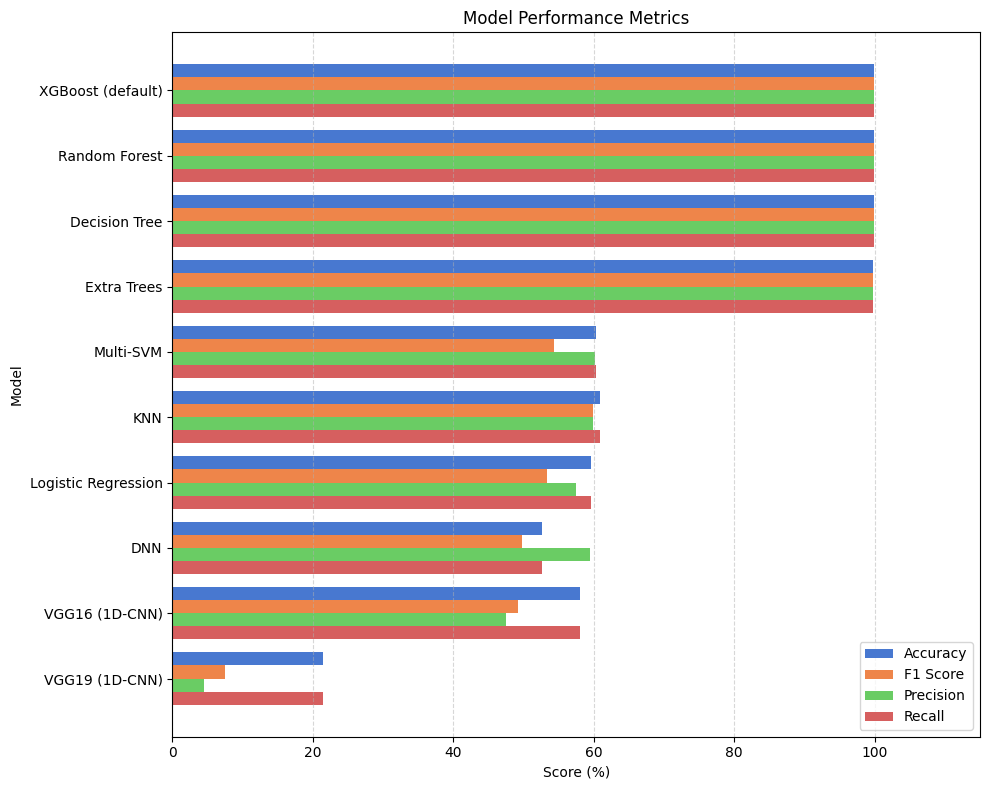

In [86]:
names     = [r.model_name for r in results]
acc       = [r.accuracy   * 100 for r in results]
f1        = [r.f1_score   * 100 for r in results]
precision = [r.precision  * 100 for r in results]
recall    = [r.recall     * 100 for r in results]

metrics      = [acc, f1, precision, recall]
metric_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
colors       = sns.color_palette('muted', 4)

y      = np.arange(len(names))
height = 0.2

fig, ax = plt.subplots(figsize=(10, 8))
for i, (vals, label, color) in enumerate(zip(metrics, metric_names, colors)):
    ax.barh(y + i * height, vals, height, label=label, color=color)

ax.set_ylabel('Model')
ax.set_xlabel('Score (%)')
ax.set_title('Model Performance Metrics')
ax.set_yticks(y + height * (len(metrics) - 1) / 2)
ax.set_yticklabels(names)
ax.set_xlim(0, 115)
ax.invert_yaxis()
ax.legend()
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


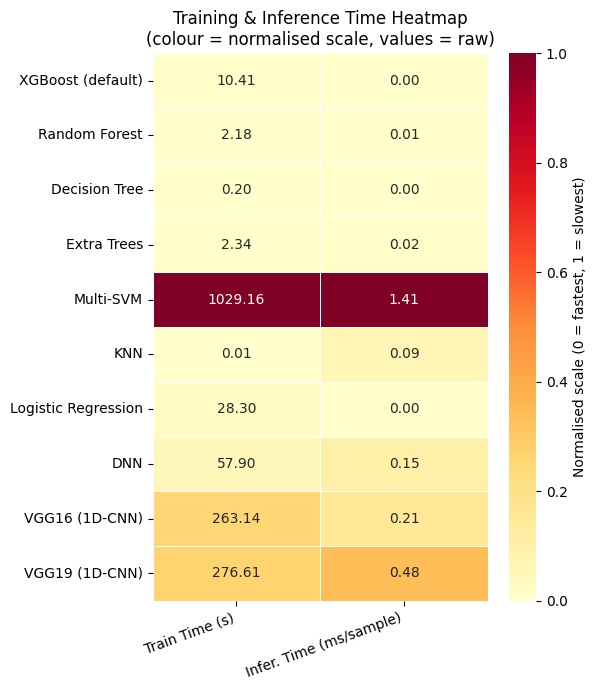

In [87]:
# Heatmap: Training time & Inference time
time_df = pd.DataFrame({
    "Train Time (s)":         [r.training_time_s   for r in results],
    "Infer. Time (ms/sample)":[r.inference_time_ms for r in results],
}, index=names)

# Min-max normalise each column for colour scale
norm_df = (time_df - time_df.min()) / (time_df.max() - time_df.min())

# Annotation strings showing raw values
annot = time_df.map(lambda v: f"{v:.2f}")

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(
    norm_df, annot=annot, fmt='', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Normalised scale (0 = fastest, 1 = slowest)'}
)
ax.set_title("Training & Inference Time Heatmap\n(colour = normalised scale, values = raw)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()